# `Homo_gridblock_Iceland.m` — Python/Jupyter port
Numerically matched port using the shared `gridblock_jupyter.py` implementation. MATLAB's geographic pair definitions, rotated-grid interpolation, accumulators, homogeneity definition, optional bootstrap, and MAT field names are retained.

In [1]:
# from pathlib import Path
# import numpy as np

# from gridblock_jupyter_iceland_pdf import run_iceland
# import sys
# import importlib

# sys.path.insert(
#     0,
#     "/meddy/simingzhang/Analysis/python/python3",
# )

# import gridblock_jupyter_iceland_pdf as gb_iceland

# gb_iceland = importlib.reload(
#     gb_iceland
# )

# # ============================================================
# # 1. 基本设置
# # ============================================================

# ini = "_rough"

# # case="wave",
# # nparticles=289

# data_root = Path(
#     "/meddy/simingzhang/Data/Parcels_data"
# )

# subdirs = {
#     "_grid": "tranV_onetime_spectukey",
#     "_rough": "tranV_onetime_roughdistr_tukey",
#     "_rough_1mon": "tranV_onetime_roughdistr_tukey",
#     "_rough_2mon": "tranV_onetime_roughdistr_tukey",

#     "_roughsmall": "tranV_onetime_roughsmallregion",
#     "_roughsmall_1mon": "tranV_onetime_roughsmallregion",
#     "_roughsmall_2mon": "tranV_onetime_roughsmallregion",
#     "_roughsmall_3mon": "tranV_onetime_roughsmallregion",

#     "_roughLASER": "tranV_onetime_roughLASER",
#     "_roughsmall_rot": "tranV_onetime_roughsmallregion_rot",
#     "_roughsmall_div": "tranV_onetime_roughsmallregion_div",

#     "_cruise": "tranV_cruise_roughsmallregion",

#     "_roughsmall_500m": "tranV_onetime_roughsmallregion_500m",
#     "_rough_500m": "tranV_onetime_rough_500m",

#     "_roughbox200g_500m": "tranV_onetime_roughbox200g_500m",
#     "_roughbox100g_500m": "tranV_onetime_roughbox100g_500m",
# }


# # ============================================================
# # 2. Eulerian reference scales
# #    单位：km
# # ============================================================

# # r_requested_km = np.array(
# #     [
# #         2.00000000,
# #         2.60352118,
# #         3.38916126,
# #         4.41187656,
# #         5.74320702,
# #         7.47628055,
# #         9.73232737,
# #         12.66916020,
# #         16.49221344,
# #         21.46891348,
# #         27.94738544,
# #         36.38080492,
# #         47.35909802,
# #         61.65020731,
# #         80.25381015,
# #         104.47124713,
# #         135.99655214,
# #         177.03495174,
# #         230.45712296,
# #         300.00000000,
# #     ],
# #     dtype=float,
# # )

# r_requested_km = np.geomspace(4.0, 300, 12)


# r_requested_km = np.sort(
#     np.unique(
#         r_requested_km[
#             np.isfinite(r_requested_km)
#             & (r_requested_km > 0)
#         ]
#     )
# )

# print("Eulerian reference scales [km]:")
# print(r_requested_km)


# # ============================================================
# # 3. 输入目录
# # ============================================================

# if ini not in subdirs:
#     raise KeyError(
#         f"Unknown ini={ini}. "
#         f"Available options are:\n{subdirs.keys()}"
#     )

# input_dir = data_root / subdirs[ini]

# print("\nInitial deployment:", ini)
# print("Input directory:", input_dir)


# # ============================================================
# # 4. N = 289 配置
# # ============================================================

# cfg_289 = dict(
#     case="wave",

#     # 只计算 289 粒子
#     nparticles=289,

#     days=89.5,
#     dt=3600.0,

#     ini=ini,

#     timerange_matlab=np.arange(
#         1,
#         1941,
#     ),

#     nblock_I=4,
#     nblock_J=4,

#     min_pairs=200,
#     min_valid_blocks=8,

#     # 保留你原来的 bootstrap 设置
#     do_bootstrap=True,
#     num_boot=1000,
#     third_pdf_reservoir_size=100000,

#     # None 表示不固定 bootstrap 随机种子
#     random_seed=None,

#     input_dir=input_dir,

#     # 使用 Eulerian 的 20 个尺度，单位 km
#     r_requested_km=r_requested_km,

#     grid_file=Path(
#         "/meddy/simingzhang/Data/RB_iceland_data/"
#         "niskin2km_500m_grd.nc"
#     ),
# )


# # ============================================================
# # 5. 运行 N = 289
# # ============================================================

# print("\nStarting Iceland calculation")
# print("Case: wave")
# print("Initial deployment:", ini)
# print("Number of particles:", cfg_289["nparticles"])
# print("Number of scales:", len(cfg_289["r_requested_km"]))
# print("Scales [km]:", cfg_289["r_requested_km"])

# result_289, output_289 = run_iceland(
#     cfg_289
# )

# print("\nCalculation finished.")
# print("Output file:")
# print(output_289)


# # ============================================================
# # 6. 检查返回结果
# # ============================================================

# print("\nReturned result fields:")

# if isinstance(result_289, dict):

#     for key, value in result_289.items():

#         shape = getattr(
#             value,
#             "shape",
#             None,
#         )

#         print(
#             f"{key:40s}",
#             type(value).__name__,
#             shape,
#         )

# else:

#     print(
#         "Warning: result_289 is not a dictionary."
#     )

#     print(
#         "Type:",
#         type(result_289),
#     )


# # ============================================================
# # 7. 检查 PDF reservoir
# # ============================================================

# if isinstance(result_289, dict):

#     if "dl_reservoir" in result_289:

#         dl_reservoir = np.asarray(
#             result_289["dl_reservoir"],
#             dtype=float,
#         )

#         print(
#             "\ndl_reservoir shape:",
#             dl_reservoir.shape,
#         )

#         if "dl_reservoir_count" in result_289:

#             dl_reservoir_count = np.asarray(
#                 result_289["dl_reservoir_count"],
#                 dtype=int,
#             ).ravel()

#             print(
#                 "dl_reservoir_count:",
#                 dl_reservoir_count,
#             )

#     else:

#         print(
#             "\nNo dl_reservoir field was returned."
#         )

#         print(
#             "The current run_iceland function may need "
#             "to be updated to save PDF samples."
#         )

Eulerian reference scales [km]:
[  4.           5.92270506   8.76960881  12.98495162  19.22650967
  28.46823653  42.15224215  62.41382448  92.41466853 136.83620626
 202.61012284 300.        ]

Initial deployment: _rough
Input directory: /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey

Starting Iceland calculation
Case: wave
Initial deployment: _rough
Number of particles: 289
Number of scales: 12
Scales [km]: [  4.           5.92270506   8.76960881  12.98495162  19.22650967
  28.46823653  42.15224215  62.41382448  92.41466853 136.83620626
 202.61012284 300.        ]


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [02:28<00:00, 13.05time/s]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat

Calculation finished.
Output file:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat

Returned result fields:
Case                                     str None
nparticles                               int None
days                                     float None
dt                                       float None
timerange                                ndarray (1940,)
r_requested_km                           ndarray (12,)
dist_axis                                ndarray (12,)
dist_bin                                 ndarray (13,)
SF1                                      ndarray (12,)
SF2                                      ndarray (12,)
SF2ll                                    ndarray (12,)
SF2tt                                    ndarray (12,)
SF3                                      ndarray (12,)
SF3lll        

In [4]:
from pathlib import Path
import gc
import importlib
import sys
import time

import numpy as np


# ============================================================
# 1. 导入最新版计算模块
# ============================================================

code_dir = Path(
    "/meddy/simingzhang/Analysis/python/python3"
)

if str(code_dir) not in sys.path:
    sys.path.insert(
        0,
        str(code_dir),
    )

import third_order_diagnostics as tod
import gridblock_jupyter_iceland_pdf as gb_iceland

importlib.invalidate_caches()

tod = importlib.reload(tod)
gb_iceland = importlib.reload(gb_iceland)

print("Diagnostics module:")
print(tod.__file__)

print("\nIceland module:")
print(gb_iceland.__file__)


# ============================================================
# 2. 检查是否加载了新的 paired-reservoir 版本
# ============================================================

test_diagnostics = tod.init_third_order(
    nscale=1,
    reservoir_size=10,
    random_seed=1,
)

tod.update_third_order(
    test_diagnostics,
    scale_bin=np.array([0, 0]),
    dl=np.array([1.0, -1.0]),
    dt=np.array([0.5, 0.5]),
)

test_output = tod.finish_third_order(
    test_diagnostics
)

required_new_fields = [
    "dl_reservoir",
    "dtr_reservoir",
    "dl3_reservoir",
    "dldtr2_reservoir",
    "d3_reservoir",
    "d3_reservoir_count",
]

missing_new_fields = [
    key
    for key in required_new_fields
    if key not in test_output
]

if missing_new_fields:
    raise RuntimeError(
        "Loaded third_order_diagnostics.py is not the "
        "new paired-reservoir version.\n"
        f"Missing fields: {missing_new_fields}\n"
        f"Loaded file: {tod.__file__}"
    )

print("\nPaired-reservoir module check passed.")


# ============================================================
# 3. 数据根目录及 ini 对应目录
# ============================================================

data_root = Path(
    "/meddy/simingzhang/Data/Parcels_data"
)

subdirs = {
    "_grid": "tranV_onetime_spectukey",

    "_rough": "tranV_onetime_roughdistr_tukey",
    "_rough_1mon": "tranV_onetime_roughdistr_tukey",
    "_rough_2mon": "tranV_onetime_roughdistr_tukey",

    "_roughsmall": "tranV_onetime_roughsmallregion",
    "_roughsmall_1mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_2mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_3mon": "tranV_onetime_roughsmallregion",

    "_roughLASER": "tranV_onetime_roughLASER",
    "_roughsmall_rot": "tranV_onetime_roughsmallregion_rot",
    "_roughsmall_div": "tranV_onetime_roughsmallregion_div",

    "_cruise": "tranV_cruise_roughsmallregion",

    "_roughsmall_500m": (
        "tranV_onetime_roughsmallregion_500m"
    ),
    "_rough_500m": "tranV_onetime_rough_500m",

    "_roughbox200g_500m": (
        "tranV_onetime_roughbox200g_500m"
    ),
    "_roughbox100g_500m": (
        "tranV_onetime_roughbox100g_500m"
    ),
}


# ============================================================
# 4. 需要计算的 case
# ============================================================

ini_cases = [
    "_rough",
    "_roughsmall",
]

flow_cases = [
    "wave",
    "nowave",
]

particle_cases = [
    289,
    625,
    1089,
]


# ============================================================
# 5. 共同尺度，单位 km
# ============================================================

r_requested_km = np.geomspace(
    4.0,
    300.0,
    12,
)

r_requested_km = np.sort(
    np.unique(
        r_requested_km[
            np.isfinite(r_requested_km)
            & (r_requested_km > 0)
        ]
    )
)

print("\nRequested scales [km]:")
print(r_requested_km)


# ============================================================
# 6. 共同设置
# ============================================================

days = 89.5
dt = 3600.0

timerange_matlab = np.arange(
    1,
    1941,
)

grid_file = Path(
    "/meddy/simingzhang/Data/RB_iceland_data/"
    "niskin2km_500m_grd.nc"
)

common_cfg = {
    "days": days,
    "dt": dt,

    "timerange_matlab": timerange_matlab,

    "nblock_I": 4,
    "nblock_J": 4,

    "min_pairs": 200,
    "min_valid_blocks": 8,

    "do_bootstrap": True,
    "num_boot": 1000,

    "r_requested_km": r_requested_km,

    "grid_file": grid_file,

    "third_pdf_reservoir_size": 100_000,
}


# ============================================================
# 7. 是否在内存中保留所有 result
#
# False 推荐：
# 12 个 case 的 reservoir 和 bootstrap 数组会占较多内存。
# 每个结果都会保存为 MAT 文件，不必全部留在内存。
# ============================================================

keep_results_in_memory = False

results = {}
output_paths = {}
completed = []
failed = []


# ============================================================
# 8. 开始批量计算
# ============================================================

total_cases = (
    len(ini_cases)
    * len(flow_cases)
    * len(particle_cases)
)

case_number = 0
all_start_time = time.perf_counter()


for ini_index, ini in enumerate(ini_cases):

    if ini not in subdirs:
        raise KeyError(
            f"Unknown ini={ini}. "
            f"Available values:\n{list(subdirs)}"
        )

    input_dir = (
        data_root
        / subdirs[ini]
    )

    if not input_dir.exists():
        raise FileNotFoundError(
            f"Input directory does not exist:\n"
            f"{input_dir}"
        )

    for flow_index, flow_case in enumerate(
        flow_cases
    ):

        for particle_index, nparticles in enumerate(
            particle_cases
        ):

            case_number += 1

            case_key = (
                ini,
                flow_case,
                nparticles,
            )

            # ------------------------------------------------
            # 为每个 case 设置可重复的随机种子
            # ------------------------------------------------

            seed_offset = (
                ini_index * 10000
                + flow_index * 1000
                + particle_index * 100
            )

            cfg = dict(
                common_cfg
            )

            cfg.update(
                {
                    "ini": ini,
                    "case": flow_case,
                    "nparticles": nparticles,
                    "input_dir": input_dir,

                    # Bootstrap 的随机种子
                    "random_seed": (
                        10001 + seed_offset
                    ),

                    # PDF reservoir 的随机种子
                    "third_pdf_random_seed": (
                        20001 + seed_offset
                    ),
                }
            )

            # ------------------------------------------------
            # 检查输入粒子文件
            #
            # run_iceland 内部使用这个命名格式
            # ------------------------------------------------

            input_file = input_dir / (
                f"{flow_case}_pars_"
                f"P{nparticles}"
                f"T{days:g}days.nc"
            )

            print(
                "\n"
                + "=" * 72
            )

            print(
                f"Case {case_number}/{total_cases}"
            )

            print(
                "ini        =",
                ini,
            )

            print(
                "case       =",
                flow_case,
            )

            print(
                "nparticles =",
                nparticles,
            )

            print(
                "input file =",
                input_file,
            )

            if not input_file.exists():

                message = (
                    "Input file does not exist"
                )

                print(
                    "SKIPPED:",
                    message,
                )

                failed.append(
                    {
                        "ini": ini,
                        "case": flow_case,
                        "nparticles": nparticles,
                        "error": message,
                        "input_file": input_file,
                    }
                )

                continue

            # ------------------------------------------------
            # 运行当前 case
            # ------------------------------------------------

            case_start_time = time.perf_counter()

            try:

                result_case, output_path = (
                    gb_iceland.run_iceland(
                        cfg
                    )
                )

                runtime = (
                    time.perf_counter()
                    - case_start_time
                )

                output_paths[
                    case_key
                ] = Path(output_path)

                # --------------------------------------------
                # 检查新字段
                # --------------------------------------------

                required_result_fields = [
                    "dist_axis",
                    "SF2",
                    "SF3",
                    "nsample",
                    "dl_reservoir",
                    "dtr_reservoir",
                    "dl3_reservoir",
                    "dldtr2_reservoir",
                    "d3_reservoir",
                    "d3_reservoir_count",
                ]

                missing = [
                    key
                    for key in required_result_fields
                    if key not in result_case
                ]

                if missing:
                    raise RuntimeError(
                        "Calculation finished, but "
                        f"fields are missing: {missing}"
                    )

                print(
                    "\nSaved:"
                )

                print(
                    output_path
                )

                print(
                    "Runtime [minutes]:",
                    runtime / 60.0,
                )

                print(
                    "dl reservoir shape:",
                    np.asarray(
                        result_case[
                            "dl_reservoir"
                        ]
                    ).shape,
                )

                print(
                    "dtr reservoir shape:",
                    np.asarray(
                        result_case[
                            "dtr_reservoir"
                        ]
                    ).shape,
                )

                print(
                    "d3 reservoir shape:",
                    np.asarray(
                        result_case[
                            "d3_reservoir"
                        ]
                    ).shape,
                )

                print(
                    "Reservoir counts:"
                )

                print(
                    np.asarray(
                        result_case[
                            "d3_reservoir_count"
                        ]
                    ).ravel()
                )

                completed.append(
                    {
                        "ini": ini,
                        "case": flow_case,
                        "nparticles": nparticles,
                        "output_path": Path(
                            output_path
                        ),
                        "runtime_seconds": runtime,
                    }
                )

                if keep_results_in_memory:

                    results[
                        case_key
                    ] = result_case

                # 不保留大型 reservoir
                del result_case
                gc.collect()

            except Exception as error:

                runtime = (
                    time.perf_counter()
                    - case_start_time
                )

                print(
                    "\nFAILED:"
                )

                print(
                    repr(error)
                )

                failed.append(
                    {
                        "ini": ini,
                        "case": flow_case,
                        "nparticles": nparticles,
                        "error": repr(error),
                        "input_file": input_file,
                        "runtime_seconds": runtime,
                    }
                )

                gc.collect()


# ============================================================
# 9. 汇总
# ============================================================

all_runtime = (
    time.perf_counter()
    - all_start_time
)

print(
    "\n"
    + "=" * 72
)

print(
    "Batch calculation finished."
)

print(
    "Completed:",
    len(completed),
    "/",
    total_cases,
)

print(
    "Failed or skipped:",
    len(failed),
)

print(
    "Total runtime [hours]:",
    all_runtime / 3600.0,
)


print(
    "\nCompleted cases:"
)

for item in completed:

    print(
        item["ini"],
        item["case"],
        item["nparticles"],
        "->",
        item["output_path"],
    )


if failed:

    print(
        "\nFailed/skipped cases:"
    )

    for item in failed:

        print(
            item["ini"],
            item["case"],
            item["nparticles"],
            "->",
            item["error"],
        )

Diagnostics module:
/meddy/simingzhang/Analysis/python/python3/third_order_diagnostics.py

Iceland module:
/meddy/simingzhang/Analysis/python/python3/gridblock_jupyter_iceland_pdf.py

Paired-reservoir module check passed.

Requested scales [km]:
[  4.           5.92270506   8.76960881  12.98495162  19.22650967
  28.46823653  42.15224215  62.41382448  92.41466853 136.83620626
 202.61012284 300.        ]

Case 1/12
ini        = _rough
case       = wave
nparticles = 289
input file = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T89.5days.nc


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [02:47<00:00, 11.61time/s]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat

Saved:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat
Runtime [minutes]: 4.149164357284705
dl reservoir shape: (12, 100000)
dtr reservoir shape: (12, 100000)
d3 reservoir shape: (12, 100000)
Reservoir counts:
[  7676  13128  26195  53787 100000 100000 100000 100000 100000 100000
 100000 100000]

Case 2/12
ini        = _rough
case       = wave
nparticles = 625
input file = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T89.5days.nc


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [10:15<00:00,  3.15time/s]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughgridBlockHL.mat

Saved:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughgridBlockHL.mat
Runtime [minutes]: 15.713578479985395
dl reservoir shape: (12, 100000)
dtr reservoir shape: (12, 100000)
d3 reservoir shape: (12, 100000)
Reservoir counts:
[ 27617  53399 100000 100000 100000 100000 100000 100000 100000 100000
 100000 100000]

Case 3/12
ini        = _rough
case       = wave
nparticles = 1089
input file = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T89.5days.nc


...

saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallgridBlockHL.mat

Saved:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallgridBlockHL.mat
Runtime [minutes]: 7.628262824068467
dl reservoir shape: (12, 100000)
dtr reservoir shape: (12, 100000)
d3 reservoir shape: (12, 100000)
Reservoir counts:
[ 53592 100000 100000 100000 100000 100000 100000 100000 100000 100000
 100000 100000]

Case 11/12
ini        = _roughsmall
case       = nowave
nparticles = 625
input file = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T89.5days.nc


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [20:51<00:00,  1.55time/s]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T1940_roughsmallgridBlockHL.mat

Saved:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T1940_roughsmallgridBlockHL.mat
Runtime [minutes]: 33.02095507333676
dl reservoir shape: (12, 100000)
dtr reservoir shape: (12, 100000)
d3 reservoir shape: (12, 100000)
Reservoir counts:
[100000 100000 100000 100000 100000 100000 100000 100000 100000 100000
 100000 100000]

Case 12/12
ini        = _roughsmall
case       = nowave
nparticles = 1089
input file = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T89.5days.nc


Iceland Lagrangian pair statistics: 100%|██████████████████| 1939/1939 [58:01<00:00,  1.80s/time]


saved /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T1940_roughsmallgridBlockHL.mat

Saved:
/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T1940_roughsmallgridBlockHL.mat
Runtime [minutes]: 113.46876670618852
dl reservoir shape: (12, 100000)
dtr reservoir shape: (12, 100000)
d3 reservoir shape: (12, 100000)
Reservoir counts:
[100000 100000 100000 100000 100000 100000 100000 100000 100000 100000
 100000 100000]

Batch calculation finished.
Completed: 12 / 12
Failed or skipped: 0
Total runtime [hours]: 7.2795283217955795

Completed cases:
_rough wave 289 -> /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat
_rough wave 625 -> /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughgridBlockHL.mat
_rough wave 1089 -> /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T1940_roughgridBlockH

# Read

In [5]:
from pathlib import Path

import numpy as np
from scipy.io import loadmat


# ============================================================
# 1. Iceland data directories
# ============================================================

data_root = Path(
    "/meddy/simingzhang/Data/Parcels_data"
)

subdirs = {
    "_grid": "tranV_onetime_spectukey",

    "_rough": "tranV_onetime_roughdistr_tukey",
    "_rough_1mon": "tranV_onetime_roughdistr_tukey",
    "_rough_2mon": "tranV_onetime_roughdistr_tukey",

    "_roughsmall": "tranV_onetime_roughsmallregion",
    "_roughsmall_1mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_2mon": "tranV_onetime_roughsmallregion",
    "_roughsmall_3mon": "tranV_onetime_roughsmallregion",

    "_roughLASER": "tranV_onetime_roughLASER",
    "_roughsmall_rot": "tranV_onetime_roughsmallregion_rot",
    "_roughsmall_div": "tranV_onetime_roughsmallregion_div",

    "_cruise": "tranV_cruise_roughsmallregion",

    "_roughsmall_500m": (
        "tranV_onetime_roughsmallregion_500m"
    ),
    "_rough_500m": (
        "tranV_onetime_rough_500m"
    ),

    "_roughbox200g_500m": (
        "tranV_onetime_roughbox200g_500m"
    ),
    "_roughbox100g_500m": (
        "tranV_onetime_roughbox100g_500m"
    ),
}


# ============================================================
# 2. Generic MAT reader
# ============================================================

def load_mat_result(path):
    """
    Read one saved MAT file and remove scipy/MATLAB metadata.
    """

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"Result file does not exist:\n{path}"
        )

    try:

        result = loadmat(
            path,
            simplify_cells=True,
        )

    except TypeError:

        # Compatibility with older scipy
        result = loadmat(
            path,
            squeeze_me=True,
            struct_as_record=False,
        )

    result = {
        key: value
        for key, value in result.items()
        if not key.startswith("__")
    }

    return result


# ============================================================
# 3. Read one Iceland result
# ============================================================

def load_iceland_result(
    ini,
    case,
    nparticles,
    timerange_end=1940,
    data_root=data_root,
    subdirs=subdirs,
):
    """
    Load one Iceland result.

    Expected filename:
        {case}_pars_P{nparticles}T{timerange_end}
        {ini}gridBlockHL.mat
    """

    if ini not in subdirs:

        raise KeyError(
            f"Unknown ini={ini}\n"
            f"Available ini values:\n"
            f"{list(subdirs.keys())}"
        )

    input_dir = (
        Path(data_root)
        / subdirs[ini]
    )

    if not input_dir.exists():

        raise FileNotFoundError(
            "Result directory does not exist:\n"
            f"{input_dir}"
        )

    filename = (
        f"{case}_pars_"
        f"P{int(nparticles)}"
        f"T{int(timerange_end)}"
        f"{ini}gridBlockHL.mat"
    )

    result_path = (
        input_dir
        / filename
    )

    # --------------------------------------------------------
    # If exact filename is absent, search a compatible result
    # --------------------------------------------------------

    if not result_path.exists():

        pattern = (
            f"{case}_pars_"
            f"P{int(nparticles)}"
            f"T*"
            f"{ini}gridBlockHL.mat"
        )

        candidates = sorted(
            input_dir.glob(
                pattern
            )
        )

        if len(candidates) == 0:

            raise FileNotFoundError(
                "Cannot find Iceland result.\n"
                f"Expected:\n{result_path}\n"
                f"Search pattern:\n"
                f"{input_dir / pattern}"
            )

        if len(candidates) > 1:

            print(
                "Multiple candidate files found:"
            )

            for candidate in candidates:
                print(
                    "   ",
                    candidate,
                )

            # Prefer exact requested timerange if available;
            # otherwise use the last sorted candidate.
            result_path = candidates[-1]

            print(
                "Using:"
            )

            print(
                "   ",
                result_path,
            )

        else:

            result_path = candidates[0]

    result = load_mat_result(
        result_path
    )

    return result, result_path


# ============================================================
# 4. Define all 12 cases
# ============================================================

ini_cases = [
    "_rough",
    "_roughsmall",
]

flow_cases = [
    "wave",
    "nowave",
]

particle_cases = [
    289,
    625,
    1089,
]

timerange_end = 1940


# ============================================================
# 5. Read all available results
#
# strict = True:
#     stop immediately if any file is missing
#
# strict = False:
#     skip missing files and continue loading the others
# ============================================================

strict = False

iceland_results = {}
iceland_paths = {}
missing_cases = []


for ini in ini_cases:

    for flow_case in flow_cases:

        for nparticles in particle_cases:

            key = (
                ini,
                flow_case,
                nparticles,
            )

            print(
                "\n"
                + "=" * 72
            )

            print(
                "Loading Iceland result:"
            )

            print(
                "  ini        =",
                ini,
            )

            print(
                "  case       =",
                flow_case,
            )

            print(
                "  nparticles =",
                nparticles,
            )

            try:

                result, result_path = (
                    load_iceland_result(
                        ini=ini,
                        case=flow_case,
                        nparticles=nparticles,
                        timerange_end=(
                            timerange_end
                        ),
                    )
                )

                iceland_results[
                    key
                ] = result

                iceland_paths[
                    key
                ] = result_path

                print(
                    "  loaded     =",
                    result_path,
                )

                print(
                    "  fields     =",
                    len(result),
                )

            except FileNotFoundError as error:

                missing_cases.append(
                    key
                )

                print(
                    "  status     = MISSING"
                )

                print(
                    error
                )

                if strict:
                    raise


# ============================================================
# 6. Create convenient named variables
#
# Missing cases become None when strict=False
# ============================================================

result_rough_wave_289 = (
    iceland_results.get(
        ("_rough", "wave", 289)
    )
)

result_rough_wave_625 = (
    iceland_results.get(
        ("_rough", "wave", 625)
    )
)

result_rough_wave_1089 = (
    iceland_results.get(
        ("_rough", "wave", 1089)
    )
)


result_rough_nowave_289 = (
    iceland_results.get(
        ("_rough", "nowave", 289)
    )
)

result_rough_nowave_625 = (
    iceland_results.get(
        ("_rough", "nowave", 625)
    )
)

result_rough_nowave_1089 = (
    iceland_results.get(
        ("_rough", "nowave", 1089)
    )
)


result_roughsmall_wave_289 = (
    iceland_results.get(
        ("_roughsmall", "wave", 289)
    )
)

result_roughsmall_wave_625 = (
    iceland_results.get(
        ("_roughsmall", "wave", 625)
    )
)

result_roughsmall_wave_1089 = (
    iceland_results.get(
        ("_roughsmall", "wave", 1089)
    )
)


result_roughsmall_nowave_289 = (
    iceland_results.get(
        ("_roughsmall", "nowave", 289)
    )
)

result_roughsmall_nowave_625 = (
    iceland_results.get(
        ("_roughsmall", "nowave", 625)
    )
)

result_roughsmall_nowave_1089 = (
    iceland_results.get(
        ("_roughsmall", "nowave", 1089)
    )
)


# ============================================================
# 7. Validate fields
# ============================================================

required_fields = [
    "dist_axis",
    "SF2",
    "SF3",
    "nsample",

    "dl_reservoir",
    "dtr_reservoir",

    "dl3_reservoir",
    "dldtr2_reservoir",
    "d3_reservoir",

    "dl_reservoir_count",
    "dtr_reservoir_count",
    "d3_reservoir_count",
]


print(
    "\n"
    + "=" * 72
)

print(
    "Loaded-result validation:"
)


valid_cases = []
incomplete_cases = []


for key, result in iceland_results.items():

    missing_fields = [
        field
        for field in required_fields
        if field not in result
    ]

    if missing_fields:

        incomplete_cases.append(
            (
                key,
                missing_fields,
            )
        )

        print(
            "\n",
            key,
            "INCOMPLETE",
        )

        print(
            "  missing fields:",
            missing_fields,
        )

    else:

        valid_cases.append(
            key
        )

        r_shape = np.asarray(
            result[
                "dist_axis"
            ]
        ).shape

        dl_shape = np.asarray(
            result[
                "dl_reservoir"
            ]
        ).shape

        dtr_shape = np.asarray(
            result[
                "dtr_reservoir"
            ]
        ).shape

        d3_shape = np.asarray(
            result[
                "d3_reservoir"
            ]
        ).shape

        print(
            "\n",
            key,
            "OK",
        )

        print(
            "  dist_axis shape     =",
            r_shape,
        )

        print(
            "  dl_reservoir shape  =",
            dl_shape,
        )

        print(
            "  dtr_reservoir shape =",
            dtr_shape,
        )

        print(
            "  d3_reservoir shape  =",
            d3_shape,
        )


# ============================================================
# 8. Check that paired reservoirs are aligned
# ============================================================

print(
    "\n"
    + "=" * 72
)

print(
    "Paired-reservoir checks:"
)


for key in valid_cases:

    result = iceland_results[
        key
    ]

    dl = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    dtr = np.asarray(
        result["dtr_reservoir"],
        dtype=float,
    )

    d3 = np.asarray(
        result["d3_reservoir"],
        dtype=float,
    )

    d3_reconstructed = (
        dl**3
        + dl * dtr**2
    )

    valid = (
        np.isfinite(d3)
        & np.isfinite(
            d3_reconstructed
        )
    )

    if np.any(valid):

        maximum_error = np.nanmax(
            np.abs(
                d3[valid]
                - d3_reconstructed[valid]
            )
        )

    else:

        maximum_error = np.nan

    print(
        key,
        "maximum reconstruction error =",
        maximum_error,
    )


# ============================================================
# 9. Final summary
# ============================================================

print(
    "\n"
    + "=" * 72
)

print(
    "Iceland loading summary"
)

print(
    "Loaded files:",
    len(iceland_results),
    "/ 12",
)

print(
    "Complete paired-reservoir cases:",
    len(valid_cases),
)

print(
    "Incomplete cases:",
    len(incomplete_cases),
)

print(
    "Missing files:",
    len(missing_cases),
)


if missing_cases:

    print(
        "\nMissing files:"
    )

    for key in missing_cases:
        print(
            "  ",
            key,
        )


if incomplete_cases:

    print(
        "\nFiles without all new reservoir fields:"
    )

    for key, fields in incomplete_cases:

        print(
            "  ",
            key,
        )

        print(
            "     missing:",
            fields,
        )


print(
    "\nAll available Iceland results are ready."
)


Loading Iceland result:
  ini        = _rough
  case       = wave
  nparticles = 289
  loaded     = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughgridBlockHL.mat
  fields     = 76

Loading Iceland result:
  ini        = _rough
  case       = wave
  nparticles = 625
  loaded     = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughgridBlockHL.mat
  fields     = 76

Loading Iceland result:
  ini        = _rough
  case       = wave
  nparticles = 1089
  loaded     = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T1940_roughgridBlockHL.mat
  fields     = 76

Loading Iceland result:
  ini        = _rough
  case       = nowave
  nparticles = 289
  loaded     = /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P289T1940_roughgridBlockHL.mat
  fields     = 76

Loading Iceland result:
  ini        = _rough
  case       = nowave
  nparticles 

# plot without MBB

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt


# # ============================================================
# # 1. 读取结果
# # ============================================================

# result = result_289

# r_km = np.asarray(
#     result["dist_axis"],
#     dtype=float,
# ).ravel()

# r_m = r_km * 1000.0

# SF2 = np.asarray(
#     result["SF2"],
#     dtype=float,
# ).ravel()

# SF3 = np.asarray(
#     result["SF3"],
#     dtype=float,
# ).ravel()

# nsample = np.asarray(
#     result["nsample"],
#     dtype=float,
# ).ravel()

# dl_reservoir = np.asarray(
#     result["dl_reservoir"],
#     dtype=float,
# )

# dl_reservoir_count = np.asarray(
#     result["dl_reservoir_count"],
#     dtype=int,
# ).ravel()


# # ============================================================
# # 2. 统一长度
# # ============================================================

# nscale = min(
#     r_km.size,
#     SF2.size,
#     SF3.size,
#     nsample.size,
#     dl_reservoir.shape[0],
#     dl_reservoir_count.size,
# )

# r_km = r_km[:nscale]
# r_m = r_m[:nscale]
# SF2 = SF2[:nscale]
# SF3 = SF3[:nscale]
# nsample = nsample[:nscale]
# dl_reservoir = dl_reservoir[:nscale]
# dl_reservoir_count = dl_reservoir_count[:nscale]


# # ============================================================
# # 3. T_total / tau_r
# # ============================================================

# T_total = float(
#     result["days"]
# ) * 86400.0

# T_total_over_tau = np.divide(
#     T_total * np.sqrt(
#         np.maximum(SF2, 0.0)
#     ),
#     r_m,
#     out=np.full(
#         nscale,
#         np.nan,
#     ),
#     where=(
#         np.isfinite(r_m)
#         & (r_m > 0)
#         & np.isfinite(SF2)
#         & (SF2 > 0)
#     ),
# )


# # ============================================================
# # 4. D3/r
# # ============================================================

# D3_over_r = np.divide(
#     SF3,
#     r_m,
#     out=np.full(
#         nscale,
#         np.nan,
#     ),
#     where=(
#         np.isfinite(r_m)
#         & (r_m > 0)
#         & np.isfinite(SF3)
#     ),
# )


# # ============================================================
# # 5. PDF helper
# # ============================================================

# def get_pdf_contribution(
#     scale_index,
#     nbins=20,
# ):

#     count = int(
#         dl_reservoir_count[scale_index]
#     )

#     count = max(
#         0,
#         min(
#             count,
#             dl_reservoir.shape[1],
#         ),
#     )

#     sample = dl_reservoir[
#         scale_index,
#         :count,
#     ]

#     sample = sample[
#         np.isfinite(sample)
#     ]

#     if sample.size == 0:
#         return None

#     xmin = np.nanmin(sample)
#     xmax = np.nanmax(sample)

#     if xmin == xmax:

#         width = max(
#             1.0,
#             abs(xmin) * 0.1,
#         )

#         xmin -= width
#         xmax += width

#     bins = np.linspace(
#         xmin,
#         xmax,
#         nbins + 1,
#     )

#     centers = 0.5 * (
#         bins[:-1]
#         + bins[1:]
#     )

#     pdf, _ = np.histogram(
#         sample,
#         bins=bins,
#         density=True,
#     )

#     contribution = (
#         centers**3 * pdf
#     )

#     return centers, contribution


# minimum_scale_index = 1
# maximum_scale_index = nscale - 1

# pdf_min = get_pdf_contribution(
#     minimum_scale_index,
# )

# pdf_max = get_pdf_contribution(
#     maximum_scale_index,
# )


# # ============================================================
# # 6. 创建 1 × 5 图
# # ============================================================

# fig, axes = plt.subplots(
#     nrows=1,
#     ncols=5,
#     figsize=(22, 4.5),
#     constrained_layout=True,
# )


# # ============================================================
# # 第一列：nsample
# # ============================================================

# ax = axes[0]

# valid = (
#     np.isfinite(r_km)
#     & (r_km > 0)
#     & np.isfinite(nsample)
#     & (nsample > 0)
# )

# rv = r_km[valid]
# nv = nsample[valid]

# if rv.size > 1:

#     log_r = np.log10(rv)

#     log_edges = np.empty(
#         rv.size + 1
#     )

#     log_edges[1:-1] = 0.5 * (
#         log_r[:-1]
#         + log_r[1:]
#     )

#     log_edges[0] = (
#         log_r[0]
#         - 0.5 * (
#             log_r[1]
#             - log_r[0]
#         )
#     )

#     log_edges[-1] = (
#         log_r[-1]
#         + 0.5 * (
#             log_r[-1]
#             - log_r[-2]
#         )
#     )

#     edges = 10.0**log_edges

#     ax.bar(
#         rv,
#         nv,
#         width=0.78 * (
#             edges[1:]
#             - edges[:-1]
#         ),
#         color="#0072B2",
#         alpha=0.8,
#         edgecolor="black",
#         linewidth=0.4,
#     )

#     ax.set_xscale("log")
#     ax.set_yscale("log")

# ax.set_xlabel(
#     "separation scale $r$ [km]"
# )

# ax.set_ylabel(
#     "number of samples"
# )

# ax.set_title(
#     "Sample count"
# )

# ax.grid(
#     True,
#     which="both",
#     alpha=0.3,
# )


# # ============================================================
# # 第二列：T_total / tau_r
# # ============================================================

# ax = axes[1]

# valid = (
#     np.isfinite(r_km)
#     & (r_km > 0)
#     & np.isfinite(T_total_over_tau)
#     & (T_total_over_tau > 0)
# )

# ax.loglog(
#     r_km[valid],
#     T_total_over_tau[valid],
#     marker="o",
#     markersize=3.5,
#     color="#D55E00",
#     linewidth=1.6,
# )

# ax.axhline(
#     1.0,
#     color="0.4",
#     linestyle=":",
#     linewidth=0.9,
# )

# ax.axhline(
#     3.0,
#     color="0.4",
#     linestyle="--",
#     linewidth=0.9,
# )

# ax.set_xlabel(
#     "separation scale $r$ [km]"
# )

# ax.set_ylabel(
#     r"$T_{\rm total}/\tau_r$"
# )

# ax.set_title(
#     "Turnover-time coverage"
# )

# ax.grid(
#     True,
#     which="both",
#     alpha=0.3,
# )


# # ============================================================
# # 第三列：D3/r
# # ============================================================

# ax = axes[2]

# valid = (
#     np.isfinite(r_km)
#     & (r_km > 0)
#     & np.isfinite(D3_over_r)
# )

# ax.semilogx(
#     r_km[valid],
#     D3_over_r[valid],
#     marker="o",
#     markersize=3.5,
#     color="#009E73",
#     linewidth=1.6,
# )

# ax.axhline(
#     0.0,
#     color="0.4",
#     linewidth=0.8,
# )

# ax.set_xlabel(
#     "separation scale $r$ [km]"
# )

# ax.set_ylabel(
#     r"$D_3(r)/r$"
# )

# ax.set_title(
#     "Third-order structure function"
# )

# ax.grid(
#     True,
#     which="both",
#     alpha=0.3,
# )


# # ============================================================
# # 第四列：最小尺度 PDF
# # ============================================================

# ax = axes[3]

# if pdf_min is not None:

#     x_pdf, y_pdf = pdf_min

#     ax.plot(
#         x_pdf,
#         y_pdf,
#         color="#0072B2",
#         linewidth=1.6,
#     )

# else:

#     ax.text(
#         0.5,
#         0.5,
#         "No PDF data",
#         ha="center",
#         va="center",
#         transform=ax.transAxes,
#     )

# ax.axhline(
#     0.0,
#     color="0.4",
#     linewidth=0.8,
# )

# ax.axvline(
#     0.0,
#     color="0.4",
#     linewidth=0.8,
# )

# ax.set_xlabel(
#     r"$\delta u_L$"
# )

# ax.set_ylabel(
#     r"$\delta u_L^3P(\delta u_L)$"
# )

# ax.set_title(
#     f"Minimum PDF\n"
#     f"$r={r_km[minimum_scale_index]:.3g}$ km"
# )

# ax.grid(
#     True,
#     alpha=0.3,
# )


# # ============================================================
# # 第五列：最大尺度 PDF
# # ============================================================

# ax = axes[4]

# if pdf_max is not None:

#     x_pdf, y_pdf = pdf_max

#     ax.plot(
#         x_pdf,
#         y_pdf,
#         color="#D55E00",
#         linewidth=1.6,
#     )

# else:

#     ax.text(
#         0.5,
#         0.5,
#         "No PDF data",
#         ha="center",
#         va="center",
#         transform=ax.transAxes,
#     )

# ax.axhline(
#     0.0,
#     color="0.4",
#     linewidth=0.8,
# )

# ax.axvline(
#     0.0,
#     color="0.4",
#     linewidth=0.8,
# )

# ax.set_xlabel(
#     r"$\delta u_L$"
# )

# ax.set_ylabel(
#     r"$\delta u_L^3P(\delta u_L)$"
# )

# ax.set_title(
#     f"Maximum PDF\n"
#     f"$r={r_km[maximum_scale_index]:.3g}$ km"
# )

# ax.grid(
#     True,
#     alpha=0.3,
# )


# # ============================================================
# # 总标题
# # ============================================================

# fig.suptitle(
#     "Iceland Lagrangian diagnostics, N = 625",
#     fontsize=14,
# )

# output_png=f'/meddy/simingzhang/Data/SF_directly/recipe_Iceland_SM{ini}_625.png'
# fig.savefig(output_png,
#     dpi=500,
#     bbox_inches="tight",
#     facecolor="white",
# )

# plt.show()

Selected diagnostic indices: [2, 6, 10]

HF selected scales:
$N=289$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=289$ effective resolution: 56.2 km
$N=625$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=625$ effective resolution: 38.4 km
$N=1,089$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=1,089$ effective resolution: 28.2 km

SM selected scales:
$N=289$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=289$ effective resolution: 56.2 km
$N=625$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=625$ effective resolution: 38.4 km
$N=1,089$ selected scales: [8.769608810251166, 42.152242150752805, 202.61012284364526]
$N=1,089$ effective resolution: 28.2 km
HF $N=289$ index = 2 r = 8.769608810251166 km
HF $N=289$ index = 6 r = 42.152242150752805 km
HF $N=289$ index = 10 r = 202.61012284364526 km
HF $N=625$ index = 2 r = 8.7696

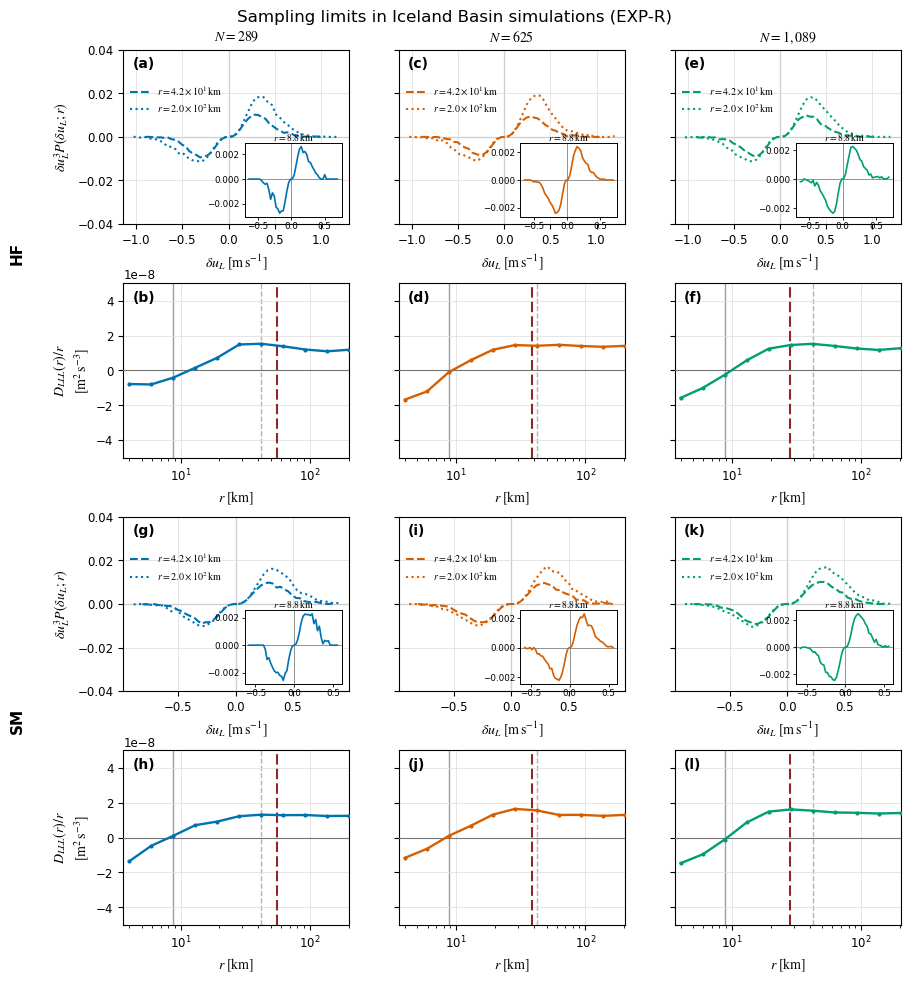

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ============================================================
# 1. Global plotting style
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 7.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})


# ============================================================
# 2. Cases and plotting properties
# ============================================================

particle_numbers = [289, 625, 1089]

particle_colors = {
    289: "#0072B2",
    625: "#D55E00",
    1089: "#009E73",
}

flow_cases = {
    "HF": "wave",
    "SM": "nowave",
}


# Initial mean particle spacing from the manuscript table [km]
initial_particle_spacing_km = {
    289: 28.1,
    625: 19.2,
    1089: 14.1,
}


# Nyquist-like effective resolution: twice the mean spacing
effective_resolution_km = {
    number: 2.0 * spacing
    for number, spacing
    in initial_particle_spacing_km.items()
}


sampling_scale_color = "#8B1A1A"
sampling_scale_linestyle = (0, (5, 2))
sampling_scale_linewidth = 1.5


# ============================================================
# 3. Diagnostic-scale and axis settings
# ============================================================

# Scale used in the PDF inset:
#   0 -> r[0]
#   1 -> r[1]
#   2 -> r[2]
SMALL_SCALE_INDEX = 2


# None selects the middle index automatically.
# Alternatively, specify an integer such as 9.
MIDDLE_SCALE_INDEX = None


# Use r[-2] as the largest displayed/diagnostic scale.
LARGE_SCALE_FROM_END = 2


NBINS = 50


# Weighted-PDF main-panel limits
PDF_YLIM = (-0.04, 0.04)


# D_LLL(r)/r limits for all six panels
D3_YLIM = (-0.5e-7, 0.5e-7)


# ============================================================
# 4. Verify required EXP-R cases
# ============================================================

required_case_keys = [
    ("_rough", flow_name, number)
    for flow_name in flow_cases.values()
    for number in particle_numbers
]


missing_case_keys = [
    key
    for key in required_case_keys
    if key not in iceland_results
]


if missing_case_keys:
    raise KeyError(
        "The following EXP-R cases were not loaded:\n"
        + "\n".join(map(str, missing_case_keys))
    )


# ============================================================
# 5. Data-reading functions
# ============================================================

def read_array(result, names, required=True):

    for name in names:

        if name in result:

            return np.ravel(
                np.asarray(
                    result[name],
                    dtype=float,
                ).squeeze()
            )

    if required:
        raise KeyError(
            f"Cannot find any field in {names}.\n"
            f"Available fields:\n{list(result.keys())}"
        )

    return None


def read_r_km(result):

    return read_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested_km",
            "r_requested",
            "r",
        ],
    )


def read_Dlll(result):

    return read_array(
        result,
        [
            "SF3lll",
            "Dlll",
            "mean_Dlll",
        ],
    )


def read_dl_reservoir(result):

    if "dl_reservoir" not in result:
        return None

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    if "dl_reservoir_count" in result:

        count = np.asarray(
            result["dl_reservoir_count"],
            dtype=int,
        ).ravel()

    else:

        count = np.full(
            raw.shape[0],
            raw.shape[1],
            dtype=int,
        )

    reservoir = []

    for index in range(raw.shape[0]):

        if index < count.size:
            number = int(count[index])
        else:
            number = raw.shape[1]

        number = max(
            0,
            min(number, raw.shape[1]),
        )

        sample = raw[index, :number]
        sample = sample[np.isfinite(sample)]

        reservoir.append(sample)

    return reservoir


# ============================================================
# 6. LaTeX scientific-notation formatter
# ============================================================

def latex_scientific(value, significant_digits=2):

    if not np.isfinite(value):
        return r"\mathrm{NaN}"

    if value == 0:
        return "0"

    exponent = int(
        np.floor(
            np.log10(abs(value))
        )
    )

    coefficient = value / 10.0**exponent
    decimals = max(0, significant_digits - 1)

    if exponent == 0:
        return f"{value:.{decimals}f}"

    return (
        rf"{coefficient:.{decimals}f}"
        rf"\times10^{{{exponent}}}"
    )


# ============================================================
# 7. Prepare HF and SM data
# ============================================================

plot_data = {
    "HF": [],
    "SM": [],
}


for flow_label, flow_name in flow_cases.items():

    for particle_number in particle_numbers:

        result = iceland_results[
            (
                "_rough",
                flow_name,
                particle_number,
            )
        ]

        r_km = read_r_km(result)
        Dlll = read_Dlll(result)
        reservoir = read_dl_reservoir(result)

        if reservoir is None:
            raise KeyError(
                "dl_reservoir is missing for "
                f"{flow_label}, N={particle_number}."
            )

        nscale = min(
            r_km.size,
            Dlll.size,
            len(reservoir),
        )

        r_km = r_km[:nscale]
        Dlll = Dlll[:nscale]
        reservoir = reservoir[:nscale]

        # D_LLL is in m^3 s^-3. Convert r from km to m.
        r_m = r_km * 1000.0

        Dlll_over_r = np.divide(
            Dlll,
            r_m,
            out=np.full_like(
                Dlll,
                np.nan,
                dtype=float,
            ),
            where=(
                np.isfinite(Dlll)
                & np.isfinite(r_m)
                & (r_m > 0)
            ),
        )

        # Remove invalid scales.
        valid_r = (
            np.isfinite(r_km)
            & (r_km > 0)
        )

        original_indices = np.flatnonzero(valid_r)

        r_km = r_km[valid_r]
        Dlll = Dlll[valid_r]
        Dlll_over_r = Dlll_over_r[valid_r]

        reservoir = [
            reservoir[int(index)]
            for index in original_indices
        ]

        # Sort by increasing separation.
        order = np.argsort(r_km)

        r_km = r_km[order]
        Dlll = Dlll[order]
        Dlll_over_r = Dlll_over_r[order]

        reservoir = [
            reservoir[int(index)]
            for index in order
        ]

        plot_data[flow_label].append({
            "particle_number": particle_number,
            "title": rf"$N={particle_number:,}$",
            "color": particle_colors[particle_number],
            "r_km": r_km,
            "Dlll": Dlll,
            "Dlll_over_r": Dlll_over_r,
            "reservoir": reservoir,
            "effective_resolution_km": (
                effective_resolution_km[particle_number]
            ),
        })


# ============================================================
# 8. Select diagnostic-scale indices
# ============================================================

all_items = (
    plot_data["HF"]
    + plot_data["SM"]
)


common_nscale = min(
    item["r_km"].size
    for item in all_items
)


if common_nscale < 4:
    raise RuntimeError(
        "At least four separation scales are required."
    )


small_scale_index = int(SMALL_SCALE_INDEX)


if MIDDLE_SCALE_INDEX is None:
    middle_scale_index = common_nscale // 2
else:
    middle_scale_index = int(MIDDLE_SCALE_INDEX)


large_scale_index = (
    common_nscale
    - LARGE_SCALE_FROM_END
)


diagnostic_indices = [
    small_scale_index,
    middle_scale_index,
    large_scale_index,
]


for name, index in [
    ("SMALL_SCALE_INDEX", small_scale_index),
    ("middle_scale_index", middle_scale_index),
    ("large_scale_index", large_scale_index),
]:

    if not 0 <= index < common_nscale:
        raise IndexError(
            f"{name}={index} is outside the valid range "
            f"0--{common_nscale - 1}."
        )


if len(set(diagnostic_indices)) < 3:
    raise ValueError(
        "The small, intermediate, and large diagnostic "
        "indices must be different."
    )


diagnostic_linestyles = [
    "-",
    "--",
    ":",
]


diagnostic_marker_colors = [
    "0.55",
    "0.65",
    "0.75",
]


print(
    "Selected diagnostic indices:",
    diagnostic_indices,
)


for flow_label in ["HF", "SM"]:

    print(f"\n{flow_label} selected scales:")

    for item in plot_data[flow_label]:

        selected_scales = [
            item["r_km"][index]
            for index in diagnostic_indices
        ]

        print(
            item["title"],
            "selected scales:",
            selected_scales,
        )

        print(
            item["title"],
            "effective resolution:",
            item["effective_resolution_km"],
            "km",
        )


# ============================================================
# 9. Build common PDF bins
#
# At each scale, the three particle-number cases within a
# simulation share the same increment bins.
# ============================================================

pdf_info = {
    "HF": {},
    "SM": {},
}


for flow_label in ["HF", "SM"]:

    for scale_index in diagnostic_indices:

        samples = []

        for item in plot_data[flow_label]:

            if scale_index >= len(item["reservoir"]):
                continue

            sample = np.asarray(
                item["reservoir"][scale_index],
                dtype=float,
            )

            sample = sample[np.isfinite(sample)]

            if sample.size > 0:
                samples.append(sample)

        if not samples:

            pdf_info[flow_label][scale_index] = None
            continue

        pooled = np.concatenate(samples)

        pdf_min = np.nanmin(pooled)
        pdf_max = np.nanmax(pooled)

        if (
            not np.isfinite(pdf_min)
            or not np.isfinite(pdf_max)
        ):

            pdf_info[flow_label][scale_index] = None
            continue

        if pdf_min == pdf_max:

            half_width = max(
                1.0,
                0.1 * abs(pdf_min),
            )

            pdf_min -= half_width
            pdf_max += half_width

        bins = np.linspace(
            pdf_min,
            pdf_max,
            NBINS + 1,
        )

        centers = 0.5 * (
            bins[:-1]
            + bins[1:]
        )

        pdf_info[flow_label][scale_index] = {
            "bins": bins,
            "centers": centers,
        }


# ============================================================
# 10. Create figure
#
# Rows:
#   0: HF weighted PDF
#   1: HF D_LLL/r
#   2: SM weighted PDF
#   3: SM D_LLL/r
#
# Columns:
#   0: N=289
#   1: N=625
#   2: N=1089
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(9.2, 10.0),
    sharex=False,
    sharey="row",
    constrained_layout=False,
)


fig.subplots_adjust(
    left=0.14,
    right=0.985,
    bottom=0.07,
    top=0.945,
    wspace=0.22,
    hspace=0.34,
)


panel_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)",
    "(j)", "(k)", "(l)",
]


panel_counter = 0


pdf_inset_axes = {
    "HF": [],
    "SM": [],
}


# ============================================================
# 11. Plot HF and SM groups
# ============================================================

for flow_label, pdf_row, d3_row in [
    ("HF", 0, 1),
    ("SM", 2, 3),
]:

    for column, item in enumerate(
        plot_data[flow_label]
    ):

        # ====================================================
        # Weighted-PDF panel
        # ====================================================

        ax = axes[pdf_row, column]

        inset_scale_x = None
        inset_scale_y = None
        inset_scale_text_r = None

        for scale_index, linestyle in zip(
            diagnostic_indices,
            diagnostic_linestyles,
        ):

            info = pdf_info[
                flow_label
            ][scale_index]

            if info is None:
                continue

            if scale_index >= len(item["reservoir"]):
                continue

            sample = np.asarray(
                item["reservoir"][scale_index],
                dtype=float,
            )

            sample = sample[np.isfinite(sample)]

            if sample.size == 0:
                continue

            pdf, _ = np.histogram(
                sample,
                bins=info["bins"],
                density=True,
            )

            contribution = (
                info["centers"]**3
                * pdf
            )

            # Use the actual scale of the current case in the
            # calculation and the displayed text.
            displayed_scale = (
                item["r_km"][scale_index]
            )

            print(
                flow_label,
                item["title"],
                "index =",
                scale_index,
                "r =",
                displayed_scale,
                "km",
            )

            # Selected small scale appears only in the inset.
            if scale_index == small_scale_index:

                inset_scale_x = (
                    info["centers"].copy()
                )

                inset_scale_y = (
                    contribution.copy()
                )

                inset_scale_text_r = (
                    displayed_scale
                )

                continue

            # Intermediate and large scales in main panel.
            ax.plot(
                info["centers"],
                contribution,
                color=item["color"],
                linestyle=linestyle,
                linewidth=1.5,
                label=(
                    rf"$r="
                    rf"{latex_scientific(displayed_scale)}"
                    rf"\,\mathrm{{km}}$"
                ),
            )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=0,
        )

        ax.axvline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=0,
        )

        if pdf_row == 0:

            ax.set_title(
                item["title"],
                fontweight="normal",
                pad=6,
            )

        ax.set_xlabel(
            r"$\delta u_L\;[\mathrm{m\,s^{-1}}]$"
        )

        if column == 0:

            ax.set_ylabel(
                r"$\delta u_L^3P(\delta u_L;r)$"
            )

        ax.set_ylim(PDF_YLIM)

        ax.grid(
            True,
            which="major",
            color="0.88",
            linewidth=0.6,
        )

        ax.tick_params(
            axis="both",
            which="both",
            direction="out",
        )

        ax.text(
            0.04,
            0.96,
            panel_labels[panel_counter],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        panel_counter += 1

        ax.legend(
            loc="upper left",
            bbox_to_anchor=(0.0, 0.84),
            frameon=False,
            handlelength=2.2,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        # ----------------------------------------------------
        # PDF inset at r[SMALL_SCALE_INDEX]
        # ----------------------------------------------------

        if (
            inset_scale_x is not None
            and inset_scale_y is not None
        ):

            axins = inset_axes(
                ax,
                width="43%",
                height="42%",
                loc="lower right",
                borderpad=0.75,
            )

            axins.plot(
                inset_scale_x,
                inset_scale_y,
                color=item["color"],
                linestyle="-",
                linewidth=1.2,
            )

            axins.axhline(
                0.0,
                color="0.5",
                linewidth=0.6,
                zorder=0,
            )

            axins.axvline(
                0.0,
                color="0.5",
                linewidth=0.6,
                zorder=0,
            )

            axins.set_title(
                rf"$r="
                rf"{latex_scientific(inset_scale_text_r)}"
                rf"\,\mathrm{{km}}$",
                fontsize=7,
                pad=2,
            )

            axins.tick_params(
                axis="both",
                which="major",
                labelsize=6.3,
                direction="out",
                length=2.4,
                width=0.6,
                pad=1.3,
            )

            axins.grid(False)

            for spine in axins.spines.values():
                spine.set_linewidth(0.7)

            pdf_inset_axes[
                flow_label
            ].append(axins)

        else:

            pdf_inset_axes[
                flow_label
            ].append(None)


        # ====================================================
        # D_LLL(r)/r panel
        # ====================================================

        ax = axes[d3_row, column]

        r_km = item["r_km"]
        Dlll_over_r = item["Dlll_over_r"]

        maximum_plot_scale = (
            r_km[large_scale_index]
        )

        valid = (
            np.isfinite(r_km)
            & (r_km > 0)
            & (r_km <= maximum_plot_scale)
            & np.isfinite(Dlll_over_r)
        )

        if not np.any(valid):

            raise ValueError(
                "No valid D_LLL/r data for "
                f"{flow_label}, "
                f"N={item['particle_number']}."
            )

        # Mark the three diagnostic scales.
        for (
            scale_index,
            scale_linestyle,
            scale_color,
        ) in zip(
            diagnostic_indices,
            diagnostic_linestyles,
            diagnostic_marker_colors,
        ):

            scale_value = r_km[scale_index]

            if (
                not np.isfinite(scale_value)
                or scale_value <= 0
                or scale_value > maximum_plot_scale
            ):
                continue

            ax.axvline(
                scale_value,
                color=scale_color,
                linestyle=scale_linestyle,
                linewidth=1.0,
                alpha=0.85,
                zorder=1,
            )

        # Effective-resolution marker.
        effective_scale = (
            item["effective_resolution_km"]
        )

        if (
            np.isfinite(effective_scale)
            and effective_scale > 0
        ):

            ax.axvline(
                effective_scale,
                color=sampling_scale_color,
                linestyle=sampling_scale_linestyle,
                linewidth=sampling_scale_linewidth,
                alpha=0.95,
                zorder=2,
            )

        ax.semilogx(
            r_km[valid],
            Dlll_over_r[valid],
            color=item["color"],
            linestyle="-",
            linewidth=1.7,
            marker="o",
            markersize=3.0,
            markerfacecolor=item["color"],
            markeredgewidth=0,
            zorder=4,
        )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=3,
        )

        ax.set_xlabel(
            r"$r\;[\mathrm{km}]$"
        )

        if column == 0:

            ax.set_ylabel(
                r"$D_{LLL}(r)/r$"
                + "\n"
                + r"$[\mathrm{m^2\,s^{-3}}]$"
            )

        # Apply ±1e-7 to every D_LLL/r panel.
        ax.set_ylim(D3_YLIM)

        ax.grid(
            True,
            which="major",
            color="0.88",
            linewidth=0.6,
            zorder=0,
        )

        ax.grid(
            False,
            which="minor",
        )

        ax.tick_params(
            axis="both",
            which="both",
            direction="out",
        )

        ax.text(
            0.04,
            0.96,
            panel_labels[panel_counter],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        panel_counter += 1

        minimum_plot_scale = np.nanmin(
            r_km[valid]
        )

        if (
            np.isfinite(effective_scale)
            and effective_scale > 0
        ):

            minimum_plot_scale = min(
                minimum_plot_scale,
                effective_scale,
            )

        ax.set_xlim(
            0.90 * minimum_plot_scale,
            maximum_plot_scale,
        )


# ============================================================
# 12. Shared HF and SM labels spanning two rows
# ============================================================

hf_pdf_position = axes[0, 0].get_position()
hf_d3_position = axes[1, 0].get_position()

sm_pdf_position = axes[2, 0].get_position()
sm_d3_position = axes[3, 0].get_position()


hf_group_center = 0.5 * (
    hf_pdf_position.y1
    + hf_d3_position.y0
)

sm_group_center = 0.5 * (
    sm_pdf_position.y1
    + sm_d3_position.y0
)


group_label_x = 0.025


fig.text(
    group_label_x,
    hf_group_center,
    "HF",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
    fontweight="bold",
)


fig.text(
    group_label_x,
    sm_group_center,
    "SM",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
    fontweight="bold",
)


# ============================================================
# 13. Overall title
# ============================================================

fig.suptitle(
    "Sampling limits in Iceland Basin simulations (EXP-R)",
    fontsize=12,
    y=0.985,
)


# ============================================================
# 14. Optional save
# ============================================================

output_png = (
    "/meddy/simingzhang/Data/SF_directly/"
    "FigC_Iceland_EXPR_sampling_limits.png"
)

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 15. Display
# ============================================================

plt.show()

Selected diagnostic indices: [0, 6, 10]

HF selected scales:
$N=289$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=289$ effective resolution: 16.4 km
$N=625$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=625$ effective resolution: 11.2 km
$N=1,089$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=1,089$ effective resolution: 8.4 km

SM selected scales:
$N=289$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=289$ effective resolution: 16.4 km
$N=625$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=625$ effective resolution: 11.2 km
$N=1,089$ selected scales: [4.0, 42.152242150752805, 202.61012284364526]
$N=1,089$ effective resolution: 8.4 km
HF $N=289$ index = 0 r = 4.0 km
HF $N=289$ index = 6 r = 42.152242150752805 km
HF $N=289$ index = 10 r = 202.61012284364526 km
HF $N=625$ index = 0 r = 4.0 km
HF $N=625$ index = 6 r = 42.152242150752805 km
HF $N=625$ index = 10 r = 202.61012284364526 km
HF $

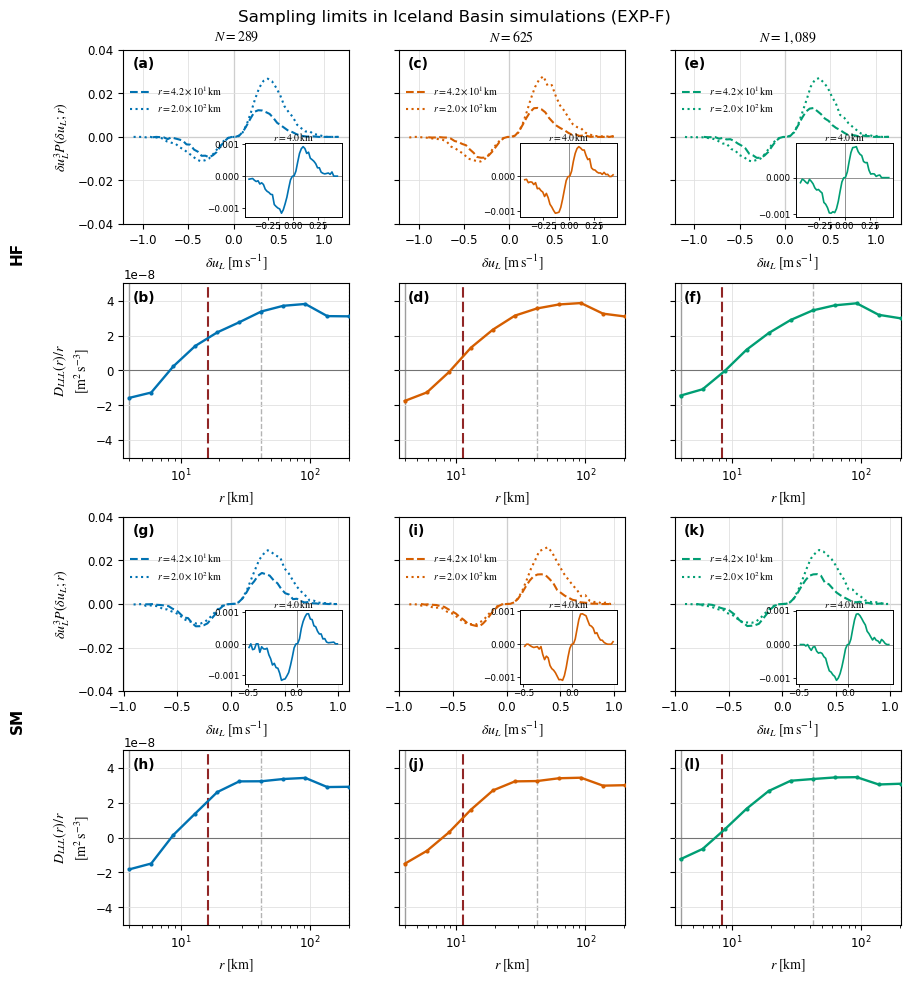

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# ============================================================
# 1. Global plotting style
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 7.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})


# ============================================================
# 2. Select deployment and cases
# ============================================================

# _roughsmall corresponds to EXP-F.
selected_ini = "_roughsmall"

particle_numbers = [
    289,
    625,
    1089,
]

particle_colors = {
    289: "#0072B2",
    625: "#D55E00",
    1089: "#009E73",
}

flow_cases = {
    "HF": "wave",
    "SM": "nowave",
}


# Initial mean particle spacings for EXP-F from Table 1 [km].
initial_particle_spacing_km = {
    289: 8.2,
    625: 5.6,
    1089: 4.2,
}


# Nyquist-like effective resolution:
# twice the initial mean particle spacing.
effective_resolution_km = {
    number: 2.0 * spacing
    for number, spacing
    in initial_particle_spacing_km.items()
}


sampling_scale_color = "#8B1A1A"
sampling_scale_linestyle = (0, (5, 2))
sampling_scale_linewidth = 1.5


# ============================================================
# 3. Diagnostic-scale and axis settings
# ============================================================

# Directly specify the small-scale index shown in the inset.
#
# Examples:
#   SMALL_SCALE_INDEX = 0  -> r[0]
#   SMALL_SCALE_INDEX = 1  -> r[1]
#   SMALL_SCALE_INDEX = 2  -> r[2]
SMALL_SCALE_INDEX = 0


# None selects the middle index automatically.
# Alternatively, specify an integer such as 9.
MIDDLE_SCALE_INDEX = None


# Use r[-2] as the largest retained diagnostic scale.
LARGE_SCALE_FROM_END = 2


# Number of histogram bins.
NBINS = 50


# Main weighted-PDF limits.
PDF_YLIM = (
    -0.04,
    0.04,
)


# Limits for all D_LLL(r)/r panels.
D3_YLIM = (
    -0.5e-7,
    0.5e-7,
)


# ============================================================
# 4. Verify required EXP-F cases
# ============================================================

required_case_keys = [
    (
        selected_ini,
        flow_name,
        particle_number,
    )
    for flow_name in flow_cases.values()
    for particle_number in particle_numbers
]


missing_case_keys = [
    key
    for key in required_case_keys
    if key not in iceland_results
]


if missing_case_keys:

    raise KeyError(
        "The following EXP-F cases were not loaded:\n"
        + "\n".join(
            map(str, missing_case_keys)
        )
    )


# ============================================================
# 5. Field readers
# ============================================================

def read_vector(result, names):
    """
    Read the first available field in names and return it as a
    flattened floating-point array.
    """

    for name in names:

        if name in result:

            return np.ravel(
                np.asarray(
                    result[name],
                    dtype=float,
                ).squeeze()
            )

    raise KeyError(
        f"Cannot find any of {names}.\n"
        f"Available fields:\n"
        f"{list(result.keys())}"
    )


def read_dl_reservoir(result):
    """
    Read longitudinal velocity-increment samples at every scale.
    """

    if "dl_reservoir" not in result:

        raise KeyError(
            "dl_reservoir is missing.\n"
            f"Available fields:\n{list(result.keys())}"
        )

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    counts = np.asarray(
        result.get(
            "dl_reservoir_count",
            np.full(
                raw.shape[0],
                raw.shape[1],
            ),
        ),
        dtype=int,
    ).ravel()

    reservoir = []

    for index in range(raw.shape[0]):

        if index < counts.size:
            number = int(counts[index])
        else:
            number = raw.shape[1]

        number = int(
            np.clip(
                number,
                0,
                raw.shape[1],
            )
        )

        sample = raw[
            index,
            :number,
        ]

        sample = sample[
            np.isfinite(sample)
        ]

        reservoir.append(sample)

    return reservoir


# ============================================================
# 6. LaTeX scientific-notation formatter
# ============================================================

def latex_scientific(value, significant_digits=2):
    """
    Format a number for a LaTeX math label.

    Examples
    --------
    200   -> 2.0\\times10^{2}
    2.7   -> 2.7
    0.025 -> 2.5\\times10^{-2}
    """

    if not np.isfinite(value):
        return r"\mathrm{NaN}"

    if value == 0:
        return "0"

    exponent = int(
        np.floor(
            np.log10(abs(value))
        )
    )

    coefficient = (
        value / 10.0**exponent
    )

    decimals = max(
        0,
        significant_digits - 1,
    )

    if exponent == 0:
        return f"{value:.{decimals}f}"

    return (
        rf"{coefficient:.{decimals}f}"
        rf"\times10^{{{exponent}}}"
    )


# ============================================================
# 7. Prepare EXP-F data
# ============================================================

plot_data = {
    "HF": [],
    "SM": [],
}


for flow_label, flow_name in flow_cases.items():

    for particle_number in particle_numbers:

        key = (
            selected_ini,
            flow_name,
            particle_number,
        )

        result = iceland_results[key]

        r_km = read_vector(
            result,
            [
                "dist_axis",
                "r_requested_km",
                "r_actual",
                "r_requested",
                "r",
            ],
        )

        Dlll = read_vector(
            result,
            [
                "SF3lll",
                "Dlll",
                "mean_Dlll",
            ],
        )

        reservoir = read_dl_reservoir(
            result
        )

        nscale = min(
            r_km.size,
            Dlll.size,
            len(reservoir),
        )

        r_km = r_km[:nscale]
        Dlll = Dlll[:nscale]
        reservoir = reservoir[:nscale]

        # D_LLL is in m^3 s^-3.
        # Convert r from km to m before calculating D_LLL/r.
        r_m = r_km * 1000.0

        Dlll_over_r = np.divide(
            Dlll,
            r_m,
            out=np.full_like(
                Dlll,
                np.nan,
                dtype=float,
            ),
            where=(
                np.isfinite(Dlll)
                & np.isfinite(r_m)
                & (r_m > 0)
            ),
        )

        # Remove invalid separation values.
        valid_r = (
            np.isfinite(r_km)
            & (r_km > 0)
        )

        original_indices = np.flatnonzero(
            valid_r
        )

        r_km = r_km[valid_r]
        Dlll = Dlll[valid_r]
        Dlll_over_r = Dlll_over_r[valid_r]

        reservoir = [
            reservoir[int(index)]
            for index in original_indices
        ]

        # Sort all fields by increasing separation.
        order = np.argsort(r_km)

        r_km = r_km[order]
        Dlll = Dlll[order]
        Dlll_over_r = Dlll_over_r[order]

        reservoir = [
            reservoir[int(index)]
            for index in order
        ]

        plot_data[flow_label].append({
            "particle_number": particle_number,
            "title": rf"$N={particle_number:,}$",
            "color": particle_colors[
                particle_number
            ],
            "r_km": r_km,
            "Dlll": Dlll,
            "Dlll_over_r": Dlll_over_r,
            "reservoir": reservoir,
            "effective_resolution_km": (
                effective_resolution_km[
                    particle_number
                ]
            ),
        })


# ============================================================
# 8. Select diagnostic-scale indices
# ============================================================

all_items = (
    plot_data["HF"]
    + plot_data["SM"]
)


common_nscale = min(
    item["r_km"].size
    for item in all_items
)


if common_nscale < 4:

    raise RuntimeError(
        "At least four separation scales are required."
    )


small_scale_index = int(
    SMALL_SCALE_INDEX
)


if MIDDLE_SCALE_INDEX is None:

    middle_scale_index = (
        common_nscale // 2
    )

else:

    middle_scale_index = int(
        MIDDLE_SCALE_INDEX
    )


large_scale_index = (
    common_nscale
    - LARGE_SCALE_FROM_END
)


diagnostic_indices = [
    small_scale_index,
    middle_scale_index,
    large_scale_index,
]


for name, index in [
    (
        "SMALL_SCALE_INDEX",
        small_scale_index,
    ),
    (
        "middle_scale_index",
        middle_scale_index,
    ),
    (
        "large_scale_index",
        large_scale_index,
    ),
]:

    if not 0 <= index < common_nscale:

        raise IndexError(
            f"{name}={index} is outside the valid range "
            f"0--{common_nscale - 1}."
        )


if len(set(diagnostic_indices)) < 3:

    raise ValueError(
        "The small, intermediate, and large diagnostic "
        "indices must be different."
    )


diagnostic_linestyles = [
    "-",
    "--",
    ":",
]


diagnostic_marker_colors = [
    "0.55",
    "0.65",
    "0.75",
]


print(
    "Selected diagnostic indices:",
    diagnostic_indices,
)


for flow_label in [
    "HF",
    "SM",
]:

    print(
        f"\n{flow_label} selected scales:"
    )

    for item in plot_data[flow_label]:

        selected_scales = [
            item["r_km"][index]
            for index in diagnostic_indices
        ]

        print(
            item["title"],
            "selected scales:",
            selected_scales,
        )

        print(
            item["title"],
            "effective resolution:",
            item["effective_resolution_km"],
            "km",
        )


# ============================================================
# 9. Build common PDF bins
#
# At a given scale, all three particle-number cases within
# one simulation use the same velocity-increment bins.
# ============================================================

pdf_info = {
    "HF": {},
    "SM": {},
}


for flow_label in [
    "HF",
    "SM",
]:

    for scale_index in diagnostic_indices:

        samples = []

        for item in plot_data[flow_label]:

            if scale_index >= len(
                item["reservoir"]
            ):
                continue

            sample = np.asarray(
                item["reservoir"][scale_index],
                dtype=float,
            )

            sample = sample[
                np.isfinite(sample)
            ]

            if sample.size > 0:
                samples.append(sample)

        if not samples:

            pdf_info[
                flow_label
            ][scale_index] = None

            continue

        pooled = np.concatenate(samples)

        lower = np.nanmin(pooled)
        upper = np.nanmax(pooled)

        if (
            not np.isfinite(lower)
            or not np.isfinite(upper)
        ):

            pdf_info[
                flow_label
            ][scale_index] = None

            continue

        if lower == upper:

            width = max(
                1.0,
                0.1 * abs(lower),
            )

            lower -= width
            upper += width

        bins = np.linspace(
            lower,
            upper,
            NBINS + 1,
        )

        centers = 0.5 * (
            bins[:-1]
            + bins[1:]
        )

        pdf_info[
            flow_label
        ][scale_index] = {
            "bins": bins,
            "centers": centers,
        }


# ============================================================
# 10. Create 4 × 3 figure
#
# Rows:
#   0: HF weighted PDFs
#   1: HF D_LLL/r
#   2: SM weighted PDFs
#   3: SM D_LLL/r
#
# Columns:
#   0: N=289
#   1: N=625
#   2: N=1089
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(9.2, 10.0),
    sharex=False,
    sharey="row",
    constrained_layout=False,
)


# Additional left margin for shared HF and SM labels.
fig.subplots_adjust(
    left=0.14,
    right=0.985,
    bottom=0.07,
    top=0.945,
    wspace=0.22,
    hspace=0.34,
)


panel_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)",
    "(j)", "(k)", "(l)",
]


panel_counter = 0


pdf_inset_axes = {
    "HF": [],
    "SM": [],
}


# ============================================================
# 11. Plot HF and SM
# ============================================================

for flow_label, pdf_row, d3_row in [
    ("HF", 0, 1),
    ("SM", 2, 3),
]:

    for column, item in enumerate(
        plot_data[flow_label]
    ):

        # ====================================================
        # Weighted longitudinal PDF
        # ====================================================

        ax = axes[
            pdf_row,
            column,
        ]

        inset_scale_x = None
        inset_scale_y = None
        inset_scale_r = None

        for scale_index, linestyle in zip(
            diagnostic_indices,
            diagnostic_linestyles,
        ):

            info = pdf_info[
                flow_label
            ][scale_index]

            if info is None:
                continue

            if scale_index >= len(
                item["reservoir"]
            ):
                continue

            sample = np.asarray(
                item["reservoir"][scale_index],
                dtype=float,
            )

            sample = sample[
                np.isfinite(sample)
            ]

            if sample.size == 0:
                continue

            pdf, _ = np.histogram(
                sample,
                bins=info["bins"],
                density=True,
            )

            contribution = (
                info["centers"]**3
                * pdf
            )

            # The displayed text uses the actual scale from
            # the current case.
            displayed_r = (
                item["r_km"][scale_index]
            )

            print(
                flow_label,
                item["title"],
                "index =",
                scale_index,
                "r =",
                displayed_r,
                "km",
            )

            # The explicitly selected small scale appears
            # only in the inset.
            if scale_index == small_scale_index:

                inset_scale_x = (
                    info["centers"].copy()
                )

                inset_scale_y = (
                    contribution.copy()
                )

                inset_scale_r = (
                    displayed_r
                )

                continue

            # Intermediate and large scales appear in the
            # main PDF panel.
            ax.plot(
                info["centers"],
                contribution,
                color=item["color"],
                linestyle=linestyle,
                linewidth=1.5,
                label=(
                    rf"$r="
                    rf"{latex_scientific(displayed_r)}"
                    rf"\,\mathrm{{km}}$"
                ),
            )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=0,
        )

        ax.axvline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=0,
        )

        if pdf_row == 0:

            ax.set_title(
                item["title"],
                fontweight="normal",
                pad=6,
            )

        ax.set_xlabel(
            r"$\delta u_L"
            r"\;[\mathrm{m\,s^{-1}}]$"
        )

        if column == 0:

            ax.set_ylabel(
                r"$\delta u_L^3"
                r"P(\delta u_L;r)$"
            )

        ax.set_ylim(
            PDF_YLIM
        )

        ax.grid(
            True,
            which="major",
            color="0.88",
            linewidth=0.6,
        )

        ax.tick_params(
            axis="both",
            which="both",
            direction="out",
        )

        ax.text(
            0.04,
            0.96,
            panel_labels[
                panel_counter
            ],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        panel_counter += 1

        ax.legend(
            loc="upper left",
            bbox_to_anchor=(
                0.0,
                0.84,
            ),
            frameon=False,
            handlelength=2.2,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        # ----------------------------------------------------
        # PDF inset at r[SMALL_SCALE_INDEX]
        # ----------------------------------------------------

        if (
            inset_scale_x is not None
            and inset_scale_y is not None
        ):

            axins = inset_axes(
                ax,
                width="43%",
                height="42%",
                loc="lower right",
                borderpad=0.75,
            )

            axins.plot(
                inset_scale_x,
                inset_scale_y,
                color=item["color"],
                linestyle="-",
                linewidth=1.2,
            )

            axins.axhline(
                0.0,
                color="0.5",
                linewidth=0.6,
                zorder=0,
            )

            axins.axvline(
                0.0,
                color="0.5",
                linewidth=0.6,
                zorder=0,
            )

            axins.set_title(
                rf"$r="
                rf"{latex_scientific(inset_scale_r)}"
                rf"\,\mathrm{{km}}$",
                fontsize=7,
                pad=2,
            )

            axins.tick_params(
                axis="both",
                which="major",
                labelsize=6.3,
                direction="out",
                length=2.4,
                width=0.6,
                pad=1.3,
            )

            axins.grid(False)

            for spine in axins.spines.values():
                spine.set_linewidth(0.7)

            pdf_inset_axes[
                flow_label
            ].append(axins)

        else:

            pdf_inset_axes[
                flow_label
            ].append(None)


        # ====================================================
        # D_LLL(r)/r
        # ====================================================

        ax = axes[
            d3_row,
            column,
        ]

        r_km = item["r_km"]
        Dlll_over_r = item["Dlll_over_r"]

        maximum_scale = (
            r_km[large_scale_index]
        )

        valid = (
            np.isfinite(r_km)
            & (r_km > 0)
            & (r_km <= maximum_scale)
            & np.isfinite(Dlll_over_r)
        )

        if not np.any(valid):

            raise ValueError(
                "No valid D_LLL/r data for "
                f"{flow_label}, "
                f"N={item['particle_number']}."
            )

        # Mark the three diagnostic scales.
        for (
            scale_index,
            scale_linestyle,
            scale_color,
        ) in zip(
            diagnostic_indices,
            diagnostic_linestyles,
            diagnostic_marker_colors,
        ):

            scale_value = (
                r_km[scale_index]
            )

            if (
                not np.isfinite(scale_value)
                or scale_value <= 0
                or scale_value > maximum_scale
            ):
                continue

            ax.axvline(
                scale_value,
                color=scale_color,
                linestyle=scale_linestyle,
                linewidth=1.0,
                alpha=0.85,
                zorder=1,
            )

        # Effective resolution based on twice the initial
        # particle spacing in EXP-F.
        effective_scale = (
            item["effective_resolution_km"]
        )

        if (
            np.isfinite(effective_scale)
            and effective_scale > 0
        ):

            ax.axvline(
                effective_scale,
                color=sampling_scale_color,
                linestyle=sampling_scale_linestyle,
                linewidth=sampling_scale_linewidth,
                alpha=0.95,
                zorder=2,
            )

        ax.semilogx(
            r_km[valid],
            Dlll_over_r[valid],
            color=item["color"],
            linestyle="-",
            linewidth=1.7,
            marker="o",
            markersize=3.0,
            markerfacecolor=item["color"],
            markeredgewidth=0,
            zorder=4,
        )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
            zorder=3,
        )

        ax.set_xlabel(
            r"$r\;[\mathrm{km}]$"
        )

        if column == 0:

            ax.set_ylabel(
                r"$D_{LLL}(r)/r$"
                + "\n"
                + r"$[\mathrm{m^2\,s^{-3}}]$"
            )

        # Apply ±1e-7 to all D_LLL/r panels.
        ax.set_ylim(
            D3_YLIM
        )

        ax.grid(
            True,
            which="major",
            color="0.88",
            linewidth=0.6,
            zorder=0,
        )

        ax.grid(
            False,
            which="minor",
        )

        ax.tick_params(
            axis="both",
            which="both",
            direction="out",
        )

        ax.text(
            0.04,
            0.96,
            panel_labels[
                panel_counter
            ],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        panel_counter += 1

        minimum_plot_scale = np.nanmin(
            r_km[valid]
        )

        if (
            np.isfinite(effective_scale)
            and effective_scale > 0
        ):

            minimum_plot_scale = min(
                minimum_plot_scale,
                effective_scale,
            )

        ax.set_xlim(
            0.90 * minimum_plot_scale,
            maximum_scale,
        )


# ============================================================
# 12. Shared HF and SM labels spanning two rows
# ============================================================

hf_pdf_position = axes[0, 0].get_position()
hf_d3_position = axes[1, 0].get_position()

sm_pdf_position = axes[2, 0].get_position()
sm_d3_position = axes[3, 0].get_position()


hf_group_center = 0.5 * (
    hf_pdf_position.y1
    + hf_d3_position.y0
)

sm_group_center = 0.5 * (
    sm_pdf_position.y1
    + sm_d3_position.y0
)


group_label_x = 0.025


fig.text(
    group_label_x,
    hf_group_center,
    "HF",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
    fontweight="bold",
)


fig.text(
    group_label_x,
    sm_group_center,
    "SM",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
    fontweight="bold",
)


# ============================================================
# 13. Overall title
# ============================================================

fig.suptitle(
    "Sampling limits in Iceland Basin simulations (EXP-F)",
    fontsize=12,
    y=0.985,
)


# ============================================================
# 14. Optional manual adjustments
# ============================================================

# Example: adjust one PDF inset.
#
# if pdf_inset_axes["HF"][0] is not None:
#     pdf_inset_axes["HF"][0].set_xlim(-0.2, 0.2)
#     pdf_inset_axes["HF"][0].set_ylim(-0.01, 0.01)


# ============================================================
# 15. Optional save
# ============================================================

output_png = (
    "/meddy/simingzhang/Data/SF_directly/"
    "FigC_Iceland_EXPF_sampling_limits.png"
)

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 16. Display
# ============================================================

plt.show()